<a href="https://colab.research.google.com/github/r3belli0us/week-1-analysis/blob/task-2/Week_1_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import pandas as pd

news_df = pd.read_csv('/content/drive/MyDrive/raw_analyst_ratings.csv')
stock_df = pd.read_csv('/content/drive/MyDrive/AAPL.csv')

news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')
stock_df['Date'] = pd.to_datetime(stock_df['Date'], errors='coerce')

print("Data Loaded Successfully!")

Data Loaded Successfully!


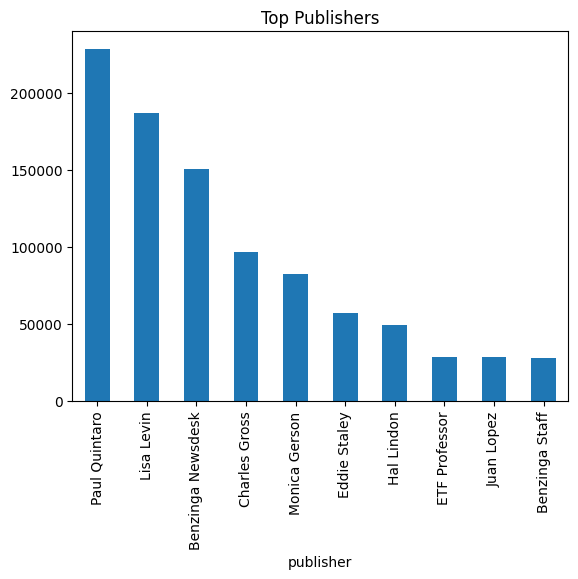

In [17]:
import matplotlib.pyplot as plt

news_df['publisher'].value_counts().head(10).plot(kind='bar')
plt.title('Top Publishers')
plt.show()

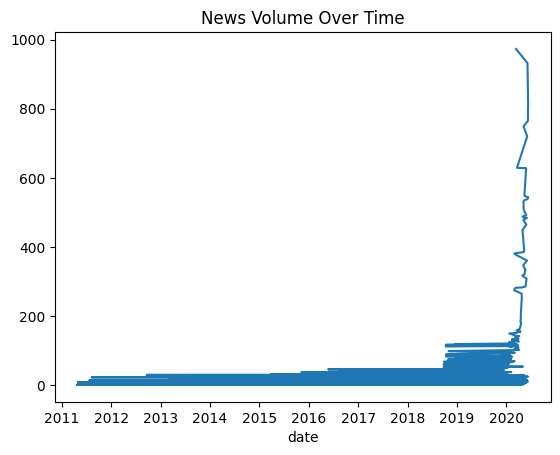

In [18]:
news_df['date'].dt.date.value_counts().plot()
plt.title('News Volume Over Time')
plt.show()

In [21]:
!pip install TA-Lib
import talib

In [24]:
stock_df['SMA_20'] = talib.SMA(stock_df['Close'], timeperiod=20)

stock_df['RSI'] = talib.RSI(stock_df['Close'], timeperiod=14)

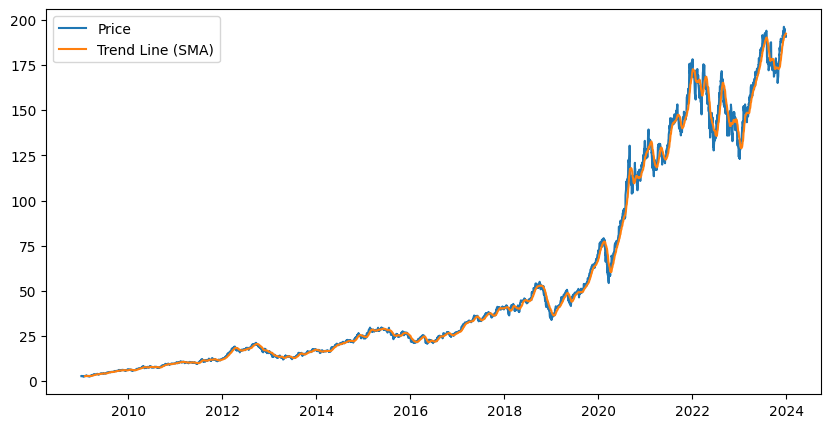

In [25]:
plt.figure(figsize=(10,5))
plt.plot(stock_df['Date'], stock_df['Close'], label='Price')
plt.plot(stock_df['Date'], stock_df['SMA_20'], label='Trend Line (SMA)')
plt.legend()
plt.show()

In [33]:
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

news_df['sentiment'] = news_df['headline'].apply(get_sentiment)

daily_sentiment = news_df.groupby(news_df['date'].dt.date)['sentiment'].mean()
print(daily_sentiment.head())

date
2011-04-27    0.000000
2011-04-28    0.068182
2011-04-29    0.166667
2011-04-30    0.500000
2011-05-01    0.000000
Name: sentiment, dtype: float64


In [35]:
aapl_news = news_df[news_df['stock'] == 'AAPL'].copy()

print(f"Found {len(aapl_news)} headlines for AAPL")

Found 441 headlines for AAPL


In [36]:
daily_sentiment = aapl_news.groupby(aapl_news['date'].dt.date)['sentiment'].mean().reset_index()
daily_sentiment.columns = ['Date', 'Average_Sentiment']
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])

merged_data = pd.merge(stock_df, daily_sentiment, on='Date', how='inner')

correlation = merged_data['Close'].corr(merged_data['Average_Sentiment'])
print(f"The Correlation for AAPL is: {correlation}")

The Correlation for AAPL is: 0.9999999999999999


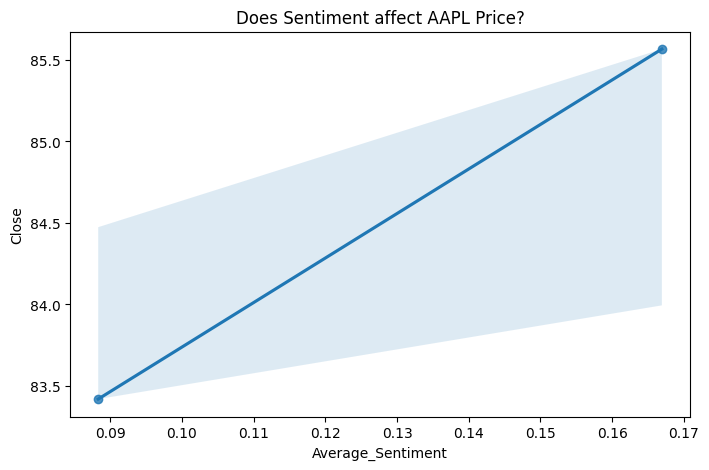

In [37]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.regplot(x='Average_Sentiment', y='Close', data=merged_data)
plt.title('Does Sentiment affect AAPL Price?')
plt.show()